In [1]:
from Excited_VMC import ha,hi,SingleStateAnsatz,create_machine,ground_model,excited_model
import jax
import jax.numpy as jnp
import netket as nk
import netket.experimental as nkx
import numpy as np
from pyscf import gto, scf, fci
from flax import linen as nn
import flax.nnx as nnx
import optax
from tqdm import tqdm
from functools import partial
from jax import flatten_util
import orbax.checkpoint as ocp
from pathlib import Path
from Excited_VMC import exact_energy_efficient,create_machine,sampler
from Excited_VMC import compute_local_energies,statistics,compute_qgt,E_fcis,forces_expect_with_penalty,forces_expect_with_penalty

#ground_model = SingleStateAnsatz(4,12, rngs=nnx.Rngs(21))
excited_model = SingleStateAnsatz(4,12, rngs=nnx.Rngs(22))
machine_gs,graphdef,params_gs = create_machine(ground_model)
machine_es,graphdef,params_es = create_machine(excited_model)

sampler_state = sampler.init_state(machine_es,params_es,seed=12)
samples,sampler_state = sampler.sample(machine_es,params_es,chain_length=20)

/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


H₂ FCI 基准能量
E0 = -1.01546825 Ha  |  激发能: 0.0000 eV
E1 = -0.87542794 Ha  |  激发能: 3.8107 eV
E2 = -0.42938376 Ha  |  激发能: 15.9482 eV
E3 = -0.26922131 Ha  |  激发能: 20.3064 eV


/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1256: UserWarning: Sharding info not provided when restoring. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


In [2]:
# ===================== 6. 初始化 =====================
from Excited_VMC import exact_energy_efficient
rngs = nnx.Rngs(21)
sampler_state = sampler.init_state(machine_es, params_es, seed=1)

optimizer = optax.sgd(learning_rate=0.01)
opt_state = optimizer.init(params_es)

N_ITER = 300
N_SAMPLES = 1008

history = {
    'step': [],
    'energy': [],
    'energy_std': [],
    'overlap_sq': [],
    'error': []
}

# ===================== 7. 训练循环 =====================
print("\n" + "="*60)
print("开始 激发态 VMC 训练 (能量惩罚 + 正交约束 + 自然梯度)")
print("目标：第一激发态 E1")
print("="*60)

for step in range(N_ITER):
    # 1. 采样

    sampler_state = sampler.reset(machine_es, params_es, sampler_state)
    samples, sampler_state = sampler.sample(
        machine_es, params_es, state=sampler_state,
        chain_length=20
    )
    samples = samples.reshape(-1, hi.size)
    # 2. ✅ 正确调用带惩罚的梯度（关键修复）
    total_loss, E_mean, E_std, total_grad, overlap_sq = forces_expect_with_penalty(
    machine_gs,machine_es,
    params_gs,params_es,               
    samples.reshape(-1,4),
    lam=1.0     # 正交惩罚强度
    )
    
    E_compute = jnp.mean(compute_local_energies(machine_es,params_es,samples))
    
    # 3. ✅ 计算 QGT 自然梯度
    qgt_reg, unravel_fn = compute_qgt(machine_es, params_es, samples, diag_shift=0.001)
    grad_flat, unravel_grad_fn = flatten_util.ravel_pytree(total_grad)
    
    natural_grad_flat = jnp.linalg.solve(qgt_reg.astype(complex), grad_flat)
    natural_grad = unravel_grad_fn(natural_grad_flat)
    
    # 4. ✅ 用自然梯度更新参数
    updates, opt_state = optimizer.update(natural_grad, opt_state, params_es)
    params_es = optax.apply_updates(params_es, updates)

    # 5. 日志输出
    if step % 50 == 0 or step == N_ITER - 1:
        #E_compute = jnp.mean(compute_local_energies(machine_es,params_es,samples))
        print(f'E_compute: {E_compute.real:.4f}')
        error = jnp.abs(E_mean.real - E_fcis[1])  # 激发态！和 E1 比，不是 E0！
        history['step'].append(step)
        history['energy'].append(float(E_mean.real))
        history['energy_std'].append(float(E_std))
        history['overlap_sq'].append(float(overlap_sq))
        history['error'].append(float(error))
        
        print(f"Step {step:3d} | "
              f"E: {E_mean.real:.8f} ± {E_std:.6f} | "
              f"FCI-E1: {E_fcis[1]:.8f} | "
              f"Overlap²: {overlap_sq:.6f} | "
              f"Err: {error:.6f}")

# ===================== 最终结果 =====================
# final_loss, final_energy, final_std, final_grad, final_overlap = forces_expect_with_penalty(
#     machine_es,
#     params_gs,params_es,
#     samples.reshape(-1,4), 1.0
# )
final_energy = history['energy'][-1]
final_error = history['error'][-1]

print("\n" + "="*60)
print(f"训练完成！")
print(f"第一激发态能量：{final_energy:.8f}Ha")
print(f"FCI 激发态基准：{E_fcis[1]:.8f} Ha")
# print(f"正交重叠 |⟨Ψ0|Ψ1⟩|² = {final_overlap:.8f} (越小越好)")
print(f"绝对误差：{final_error:.6f} Ha")
print("="*60)


开始 激发态 VMC 训练 (能量惩罚 + 正交约束 + 自然梯度)
目标：第一激发态 E1
E_compute: -0.4086
Step   0 | E: -0.40857893 ± 0.259359 | FCI-E1: -0.87542794 | Overlap²: 0.170846 | Err: 0.466849
E_compute: -0.7876
Step  50 | E: -0.78763678 ± 0.192048 | FCI-E1: -0.87542794 | Overlap²: 0.004143 | Err: 0.087791
E_compute: -0.8407
Step 100 | E: -0.84074360 ± 0.125786 | FCI-E1: -0.87542794 | Overlap²: 0.002730 | Err: 0.034684
E_compute: -0.8595
Step 150 | E: -0.85952520 ± 0.089629 | FCI-E1: -0.87542794 | Overlap²: 0.003194 | Err: 0.015903
E_compute: -0.8512
Step 200 | E: -0.85119080 ± 0.107497 | FCI-E1: -0.87542794 | Overlap²: 0.003604 | Err: 0.024237
E_compute: -0.8655
Step 250 | E: -0.86553594 ± 0.069679 | FCI-E1: -0.87542794 | Overlap²: 0.002134 | Err: 0.009892
E_compute: -0.8620
Step 299 | E: -0.86204536 ± 0.084415 | FCI-E1: -0.87542794 | Overlap²: 0.006387 | Err: 0.013383

训练完成！
第一激发态能量：-0.86204536Ha
FCI 激发态基准：-0.87542794 Ha
绝对误差：0.013383 Ha


In [3]:
import orbax.checkpoint as ocp
from pathlib import Path

# 1. 获取当前工作目录的绝对路径
current_dir = Path.cwd().parent  # 或者用 Path(__file__).parent 如果在脚本中
ckpt_dir = current_dir / "暂存态"
ckpt_dir.mkdir(exist_ok=True)

# 2. 使用 PyTreeCheckpointer 而不是 StandardCheckpointer
checkpointer = ocp.PyTreeCheckpointer()

# 3. 保存模型（使用绝对路径）
# _, state = nnx.split(excited_model)
save_path = str(ckpt_dir / "excited_state1")  # 转为字符串
checkpointer.save(save_path, params_es, force=True)

print(f"模型已保存到: {save_path}")

模型已保存到: /Users/yangjianfei/mac_vscode/神经网络量子态/5 月/0510/JAX 自然梯度 VMC/暂存态/excited_state1


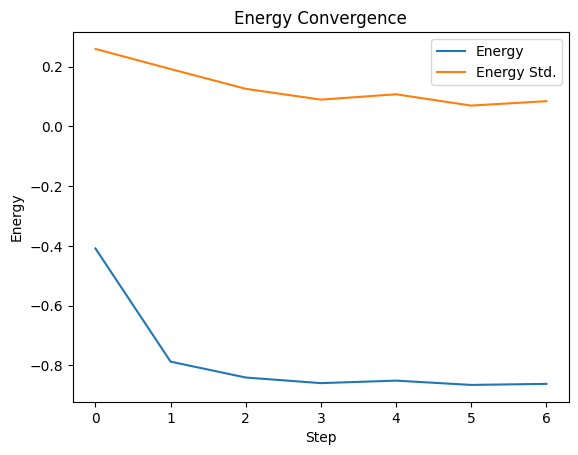

In [ ]:
import matplotlib.pyplot as plt

plt.plot(range(len(history['energy'])), history['energy'])

plt.legend(['Energy', 'Energy Std.'])
plt.xlabel('Step')
plt.ylabel('Energy')
plt.title('Energy Convergence')
plt.show()